# Extension 2 -- Exploratory Sector-Contrast Heterogeneity (DR-Learner)

**Revised 2026-09-27 following an external implementation review.** The previous version fitted Stage 1
(nuisance models) and Stage 2 (the CATE model) on two *independently* respondent-grouped fold splits and
called the result "honest." That is not fully justified: Stage 2's training pseudo-outcomes were generated by
Stage-1 models that, because the two splits were independent, could have been fit on data including some of
Stage 2's own held-out respondents -- an unaudited cross-stage information path, not a proven end-to-end
holdout. This revision instead uses a single respondent-grouped **development/test split**: Stage 1, Stage 2,
preprocessing, and quantile-bin thresholds are *all* fit on the development portion only, and the test portion
is never touched by any fitting step before being scored -- a simpler, fully auditable design at the cost of a
smaller effective validation sample. The current `README.md` and `outputs/` describe the completed local run; archived outputs from the
previous design must not be reported. The held-out test set has 80,241 records. Tied predictions yield
four unequal groups, not quintiles. Held-out weighted pseudo-outcome prediction R-squared is 0.0061,
so personalized ranking is weak. Development pseudo-outcomes use respondent-grouped, cross-fitted nuisance predictions within
development. Separate final nuisance fits on all development records score the held-out test set.

**Research question.** Among observed patient and contextual characteristics, where does the adjusted
private-vs-public Cesarean contrast appear larger or smaller?

**Relationship to the frozen V2 pipeline.** This notebook does not modify anything under `notebooks/v2/` or
`outputs/`. It reuses the same public/private analytic cohort and the same 8-variable confounder set as
`notebooks/v2/07_aipw_primary_analysis.ipynb`.

**Method, stated precisely.** This is a DR-learner (Kennedy, 2023, *Electronic Journal of Statistics*, DOI
10.1214/23-EJS2157): compute the doubly-robust AIPW pseudo-outcome `tau_hat = psi1 - psi0` for the sector
contrast, then regress it on a *pre-specified* set of pre-exposure moderators with a `RandomForestRegressor`
fit on the development split only, scored on the untouched test split.

**Interpretation rule, repeated at the end:** any heterogeneity found here is *exploratory adjusted-effect
heterogeneity*, not personalized causal truth, is only as credible as the primary AIPW analysis's own
selection-on-observables assumption, and is validated on a single test split, not independently replicated.

**Run status.** Completed locally on 27 September 2026. Documentation-only changes here do not
require rerunning the expensive bootstrap cells.

## 1. Imports, shared config/utils

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance

sys.path.append(str(Path("../shared").resolve()))
import config
import utils

pd.set_option("display.max_columns", None)

OUTPUTS_DIR = config.EXT02_OUTPUTS_DIR
RANDOM_STATE = config.RANDOM_STATE
N_FOLDS = config.N_FOLDS

## 2. Load the same public/private analytic cohort as Notebook 07

In [2]:
analytic, n_loaded, n_other = utils.load_public_private_analytic(
    config.V2_PROCESSED_DATA_PATH,
    expected_total_rows=config.EXPECTED_V2_ROW_COUNT,
    expected_analytic_rows=config.EXPECTED_ANALYTIC_ROW_COUNT,
)
print(f"Loaded df_model_v2: {n_loaded} rows. Excluded 'other' facility records: {n_other}.")
print(f"Analytic sample (public + private): {len(analytic)}")
print(analytic["exposure"].value_counts().rename({0: "public", 1: "private"}))

Loaded df_model_v2: 201311 rows. Excluded 'other' facility records: 517.
Analytic sample (public + private): 200794
exposure
public     150299
private     50495
Name: count, dtype: int64


## 3. Confounder set for the nuisance models (identical to notebooks/v2/06-07)

In [3]:
numeric_confounders = config.NUMERIC_CONFOUNDERS
categorical_confounders = config.CATEGORICAL_CONFOUNDERS
confounder_cols = config.CONFOUNDER_COLS
print(f"Confounder set ({len(confounder_cols)}): {confounder_cols}")

Confounder set (8): ['birth_order', 'wealth_index', 'education_years', 'residence', 'religion', 'social_group', 'twin_order', 'state']


## 4. Pre-specified moderator set -- fixed BEFORE inspecting any heterogeneity result

Per the handoff (step 15), the moderator set below is decided here, before any CATE model is fit or any
heterogeneity result is inspected. See `../shared/data_dictionary.md` for the full rationale for each variable
and for what is explicitly excluded.

In [4]:
PRIMARY_MODERATORS_NUMERIC = ["wealth_index", "education_years"]
PRIMARY_MODERATORS_CATEGORICAL = ["residence", "social_group", "state", "twin_order"]
PRIMARY_MODERATORS = PRIMARY_MODERATORS_NUMERIC + PRIMARY_MODERATORS_CATEGORICAL

forbidden_as_moderator = {
    "anc_visits", "anc_doctor", "anc_nurse_midwife", "anc_traditional_attendant",
    "anc_community_worker", "anc_anganwadi_worker", "anc_asha_worker", "anc_other_provider",
    "no_anc_provider", "first_anc_timing", "weight_measured_during_pregnancy",
    "bp_measured_during_pregnancy", "urine_sample_during_pregnancy", "blood_sample_during_pregnancy",
    "told_about_pregnancy_complications", "counselled_vaginal_bleeding", "counselled_convulsions",
    "counselled_prolonged_labour", "counselled_severe_abdominal_pain", "counselled_high_blood_pressure",
    "facility_type", "delivery_place_code", "csection",
    "risk_stratum_primary", "risk_stratum_refined_sensitivity", "first_birth",
    "convulsions_during_pregnancy", "swelling_during_pregnancy",
}

overlap = forbidden_as_moderator.intersection(set(PRIMARY_MODERATORS))
assert not overlap, f"Forbidden/post-exposure variable found in moderator set: {overlap}"
print(f"Primary moderator set ({len(PRIMARY_MODERATORS)}): {PRIMARY_MODERATORS}")
print("No mediator/post-exposure/forbidden variable in the moderator set.")

Primary moderator set (6): ['wealth_index', 'education_years', 'residence', 'social_group', 'state', 'twin_order']
No mediator/post-exposure/forbidden variable in the moderator set.


## 5. Development / test split (handoff-review repair: replaces the old two-independently-folded-stage design)

A single `GroupShuffleSplit` on `respondent_id` (60% development / 40% test). **Every** subsequent fitting
step -- Stage-1 nuisance cross-fitting, preprocessing (imputation/encoding), the Stage-2 CATE model, and the
quantile-bin thresholds -- is fit on `dev` only. `test` is scored, never fit, by anything. This is the "simpler,
fully auditable" design the review explicitly endorses as an acceptable alternative to a full nested
cross-fitting scheme, at the documented cost of a smaller effective validation sample and less stable rare
categories.

In [5]:
TEST_SIZE = 0.4
splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
dev_idx, test_idx = next(splitter.split(analytic, groups=analytic["respondent_id"]))

dev_respondents = set(analytic["respondent_id"].to_numpy()[dev_idx])
test_respondents = set(analytic["respondent_id"].to_numpy()[test_idx])
assert not (dev_respondents & test_respondents), "Respondent overlap between development and test splits."

dev = analytic.iloc[dev_idx].reset_index(drop=True).copy()
test = analytic.iloc[test_idx].reset_index(drop=True).copy()
print(f"Development: {len(dev)} records ({len(dev_respondents)} respondents)")
print(f"Test (untouched by all fitting below): {len(test)} records ({len(test_respondents)} respondents)")

Development: 120553 records (94855 respondents)
Test (untouched by all fitting below): 80241 records (63237 respondents)


## 6. Stage 1 -- nuisance models, fit on development only, scored onto test

The frozen Notebook 07 predictions cannot be reused for this development/test design, even with a
birth-level merge key: they were cross-fitted on the **full cohort**, so some nuisance fits already used
respondents in this extension's test split. Development's nuisance predictions are cross-fitted within
development only. A propensity model and an outcome model fit on all development records then score
the test records, which are never used in any fitting step.


In [6]:
# The primary notebook's cross-fitted nuisances used the entire cohort during fitting.
# Reusing them would expose test respondents to development-stage nuisance models.
# Refit within development, then score the held-out test set with models fit on development only.
REUSED_NOTEBOOK07_NUISANCES = False
print("Refitting Stage-1 nuisances within development; no full-cohort prediction reuse.")


Refitting Stage-1 nuisances within development; no full-cohort prediction reuse.


In [7]:
def build_W(df):
    W = df[confounder_cols].copy()
    for col in categorical_confounders:
        W[col] = W[col].astype("string").fillna("Missing").astype(str)
    return W


W_dev = build_W(dev)
e_hat_dev_raw, mu1_hat_dev, mu0_hat_dev, dev_fold_assignments = utils.cross_fit_nuisances(
    W_dev, dev["exposure"].to_numpy(), dev["csection"].astype(int).to_numpy(),
    dev["respondent_id"].to_numpy(), dev["sample_weight_normalized"].to_numpy(),
    numeric_confounders, categorical_confounders,
    n_folds=N_FOLDS, random_state=RANDOM_STATE, outcome_model_type="xgboost",
)
e_hat_dev = np.clip(e_hat_dev_raw, config.CLIP_EPS, 1 - config.CLIP_EPS)

# Single fit on the ENTIRE development set (no cross-fitting needed -- test rows never touch this fit).
final_propensity = utils.make_propensity_pipeline(numeric_confounders, categorical_confounders, RANDOM_STATE)
final_propensity.fit(W_dev, dev["exposure"], clf__sample_weight=dev["sample_weight_normalized"])

final_outcome = utils.make_outcome_pipeline(numeric_confounders, categorical_confounders, RANDOM_STATE, "xgboost")
W_dev_with_exposure = W_dev.copy()
W_dev_with_exposure["exposure"] = dev["exposure"].to_numpy()
final_outcome.fit(W_dev_with_exposure, dev["csection"].astype(int), clf__sample_weight=dev["sample_weight_normalized"])

W_test = build_W(test)
e_hat_test_raw = final_propensity.predict_proba(W_test)[:, 1]
e_hat_test = np.clip(e_hat_test_raw, config.CLIP_EPS, 1 - config.CLIP_EPS)
W_test_treated = W_test.copy(); W_test_treated["exposure"] = 1
W_test_control = W_test.copy(); W_test_control["exposure"] = 0
mu1_hat_test = final_outcome.predict_proba(W_test_treated)[:, 1]
mu0_hat_test = final_outcome.predict_proba(W_test_control)[:, 1]

print(f"Development nuisances ready: {len(dev)} rows. Test nuisances ready (scored, never fit on): {len(test)} rows.")


Development nuisances ready: 120553 rows. Test nuisances ready (scored, never fit on): 80241 rows.


## 7. Sanity check -- development-set AIPW estimate vs. the frozen primary result

In [8]:
outcome_dev = dev["csection"].astype(int).to_numpy()
exposure_dev = dev["exposure"].to_numpy()
weight_dev = dev["sample_weight_normalized"].to_numpy()

r1_dev, r0_dev, rd_dev, rr_dev = utils.aipw_point_estimate(outcome_dev, exposure_dev, e_hat_dev, mu1_hat_dev, mu0_hat_dev, weight_dev)
print(f"Development-only AIPW risk difference: {rd_dev * 100:.2f} pp | risk ratio: {rr_dev:.3f} "
      f"(computed on {len(dev)} of {len(analytic)} rows -- not expected to exactly match the full-cohort "
      f"frozen primary estimate, since this is a 60% subsample).")

frozen_path = config.V2_FINAL_TABLES_DIR / "final_aipw_overall_table.csv"
if frozen_path.exists():
    frozen = pd.read_csv(frozen_path)
    print("\nFrozen full-cohort primary result (outputs/final_tables/final_aipw_overall_table.csv):")
    print(frozen)

Development-only AIPW risk difference: 28.90 pp | risk ratio: 2.743 (computed on 120553 of 200794 rows -- not expected to exactly match the full-cohort frozen primary estimate, since this is a 60% subsample).

Frozen full-cohort primary result (outputs/final_tables/final_aipw_overall_table.csv):
   r1_hat_private_risk_pct  r0_hat_public_risk_pct  risk_difference_pct  \
0                  44.9644               16.494602            28.469798   

   risk_difference_ci_low_pct  risk_difference_ci_high_pct  risk_ratio  \
0                   27.671957                    29.244259    2.726007   

   risk_ratio_ci_low  risk_ratio_ci_high  n_analytic  n_private  n_public  \
0           2.656604            2.803453      200794      50495    150299   

   n_extreme_propensity  trimmed_sensitivity_rd_pct  trimmed_sensitivity_rr  
0                 17501                         NaN                     NaN  


## 8. Per-record AIPW pseudo-outcome (development and test)

`tau_hat_i = psi1_i - psi0_i` is computed for both splits using each split's own out-of-fit nuisance
predictions. Development's `tau_hat` is the Stage-2 training target; test's `tau_hat` is used only later, to
evaluate realized effects on genuinely unseen rows.

In [9]:
psi1_dev, psi0_dev = utils.aipw_psi(outcome_dev, exposure_dev, e_hat_dev, mu1_hat_dev, mu0_hat_dev)
tau_hat_dev = psi1_dev - psi0_dev

outcome_test = test["csection"].astype(int).to_numpy()
exposure_test = test["exposure"].to_numpy()
weight_test = test["sample_weight_normalized"].to_numpy()
psi1_test, psi0_test = utils.aipw_psi(outcome_test, exposure_test, e_hat_test, mu1_hat_test, mu0_hat_test)
tau_hat_test = psi1_test - psi0_test

print(f"Development tau_hat: mean {np.average(tau_hat_dev, weights=weight_dev) * 100:.2f} pp (n={len(dev)})")
print(f"Test tau_hat: mean {np.average(tau_hat_test, weights=weight_test) * 100:.2f} pp (n={len(test)})")

Development tau_hat: mean 28.90 pp (n=120553)
Test tau_hat: mean 28.24 pp (n=80241)


## 9. Stage 2 -- CATE model, fit on development only (fold-local preprocessing repair)

**Preprocessing-leakage repair.** The previous version fit the one-hot encoder and numeric imputers on the
*entire* cohort before any fold split. This version fits them on **development only** and applies the
already-fit transform to test -- test rows never influence an imputation median or a category's encoding.

In [10]:
def build_moderator_matrix(df, encoder, numeric_medians):
    X = df[PRIMARY_MODERATORS].copy()
    for col in PRIMARY_MODERATORS_CATEGORICAL:
        X[col] = X[col].astype("string").fillna("Missing").astype(str)
    for col in PRIMARY_MODERATORS_NUMERIC:
        X[col] = X[col].fillna(numeric_medians[col])
    X_cat = encoder.transform(X[PRIMARY_MODERATORS_CATEGORICAL])
    return np.hstack([X[PRIMARY_MODERATORS_NUMERIC].to_numpy(), X_cat])


numeric_medians_dev = {col: dev[col].median() for col in PRIMARY_MODERATORS_NUMERIC}

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
dev_cat_for_fit = dev[PRIMARY_MODERATORS_CATEGORICAL].astype("string").fillna("Missing").astype(str)
encoder.fit(dev_cat_for_fit)
cat_feature_names = list(encoder.get_feature_names_out(PRIMARY_MODERATORS_CATEGORICAL))
feature_names = PRIMARY_MODERATORS_NUMERIC + cat_feature_names

# Map each encoded feature name back to its source variable, for importance aggregation later.
feature_to_variable = {name: name for name in PRIMARY_MODERATORS_NUMERIC}
for cat_col in PRIMARY_MODERATORS_CATEGORICAL:
    for encoded_name in cat_feature_names:
        if encoded_name.startswith(cat_col + "_"):
            feature_to_variable[encoded_name] = cat_col

X_dev = build_moderator_matrix(dev, encoder, numeric_medians_dev)
X_test = build_moderator_matrix(test, encoder, numeric_medians_dev)

print(f"Moderator design matrix -- development: {X_dev.shape}, test: {X_test.shape} (fit on development only)")

Moderator design matrix -- development: (120553, 49), test: (80241, 49) (fit on development only)


In [11]:
cate_model = RandomForestRegressor(
    n_estimators=500, max_depth=6, min_samples_leaf=200,
    random_state=RANDOM_STATE, n_jobs=-1,
)
cate_model.fit(X_dev, tau_hat_dev, sample_weight=weight_dev)

tau_pred_dev = cate_model.predict(X_dev)
tau_pred_test = cate_model.predict(X_test)
print("Stage-2 CATE model fit on development only. Predicted for both development (in-sample, for reference "
      "only) and test (genuinely out-of-sample -- test was never used to fit this model, its preprocessing, "
      "or Stage 1).")

Stage-2 CATE model fit on development only. Predicted for both development (in-sample, for reference only) and test (genuinely out-of-sample -- test was never used to fit this model, its preprocessing, or Stage 1).


## 10. Grouped permutation importance on a held-out test subset

The old impurity ranking of separate state dummies could not be interpreted as a share of explained
heterogeneity. Here each original moderator is permuted as a whole before the development-fitted
encoder transforms it, preserving a valid one-hot pattern. The weighted R² drop is evaluated on a
reproducible subset of at most 10,000 test birth records with five permutations per variable. This is
an exploratory ranking based on noisy pseudo-outcomes; inspect baseline held-out R² and the spread of
permutation results before interpreting any rank. The other test rows remain for the bin validation.


In [12]:
# Permute one original variable at a time, so all its one-hot columns change together.
# A reproducible test subset limits the number of forest predictions during importance.
from sklearn.metrics import r2_score

IMPORTANCE_TEST_N = min(10000, len(test))
IMPORTANCE_REPEATS = 5
importance_rng = np.random.RandomState(RANDOM_STATE + 101)
importance_idx = importance_rng.choice(len(test), size=IMPORTANCE_TEST_N, replace=False)
importance_frame = test.iloc[importance_idx].reset_index(drop=True)
importance_target = tau_hat_test[importance_idx]
importance_weight = weight_test[importance_idx]
importance_matrix = build_moderator_matrix(importance_frame, encoder, numeric_medians_dev)
base_r2 = r2_score(importance_target, cate_model.predict(importance_matrix), sample_weight=importance_weight)

importance_rows = []
for variable in PRIMARY_MODERATORS:
    drops = []
    for repeat in range(IMPORTANCE_REPEATS):
        changed = importance_frame[PRIMARY_MODERATORS].copy()
        changed[variable] = changed[variable].to_numpy()[importance_rng.permutation(IMPORTANCE_TEST_N)]
        changed_matrix = build_moderator_matrix(changed, encoder, numeric_medians_dev)
        permuted_r2 = r2_score(importance_target, cate_model.predict(changed_matrix), sample_weight=importance_weight)
        drops.append(base_r2 - permuted_r2)
    importance_rows.append({"variable": variable, "importance_mean": float(np.mean(drops)),
                            "importance_std": float(np.std(drops, ddof=1))})

modifier_summary = pd.DataFrame(importance_rows).sort_values("importance_mean", ascending=False).reset_index(drop=True)
modifier_summary["rank"] = modifier_summary.index + 1
modifier_summary.to_csv(OUTPUTS_DIR / "heterogeneity_modifier_summary.csv", index=False)
print(f"Held-out weighted R² on importance subset: {base_r2:.4f}; rows: {IMPORTANCE_TEST_N}; repeats: {IMPORTANCE_REPEATS}")
print("Saved:", OUTPUTS_DIR / "heterogeneity_modifier_summary.csv")
print("Importance is the change in held-out R² after jointly permuting each original variable; negative values are possible.")
modifier_summary


Held-out weighted R² on importance subset: 0.0061; rows: 10000; repeats: 5
Saved: C:\Users\Tushna\IPD\extensions_work\02_causal_heterogeneity\outputs\heterogeneity_modifier_summary.csv
Importance is the change in held-out R² after jointly permuting each original variable; negative values are possible.


,variable,importance_mean,importance_std,rank
0,state,1.212945e-02,2.200802e-03,1
1,wealth_index,9.093076e-04,4.163035e-04,2
2,residence,6.657899e-04,5.549618e-04,3
3,twin_order,-2.220446e-17,4.965068e-17,4
4,education_years,-1.958444e-04,1.031473e-03,5
5,social_group,-3.767599e-04,1.874814e-05,6


In [14]:
print("Cut points:", np.quantile(tau_pred_dev, np.linspace(0, 1, 6)))
print("Distinct predictions:", len(np.unique(tau_pred_dev)))

Cut points: [-0.04520389  0.284737    0.30382717  0.30382717  0.30479105  0.76459104]
Distinct predictions: 2517


## 11. Ordered predicted-contrast groups on test

The intended five quantile positions were calculated from development predictions. Duplicate interior
cut points are dropped to keep ties together, then the development-derived thresholds are applied to
test. This run produced four unequal groups Q1-Q4, not literal quintiles. The internal name
`cate_quintile` is retained for compatibility with the executed results.


In [15]:
requested_bins = 5
cut_points = np.quantile(tau_pred_dev, np.linspace(0, 1, requested_bins + 1))
interior = np.unique(cut_points[1:-1])
interior = interior[(interior > tau_pred_dev.min()) & (interior < tau_pred_dev.max())]
bin_edges = np.r_[-np.inf, interior, np.inf]

N_QUANTILE_BINS = len(bin_edges) - 1
BIN_LABELS = [f"Q{i+1}" for i in range(N_QUANTILE_BINS)]
assert N_QUANTILE_BINS >= 2

test = test.copy()
test["tau_pred"] = tau_pred_test
test["cate_quintile"] = pd.cut(
    tau_pred_test, bins=bin_edges, labels=BIN_LABELS, include_lowest=True
)

bin_counts = test["cate_quintile"].value_counts().sort_index()
print(f"Usable ordered groups: {N_QUANTILE_BINS}")
print(bin_counts)
assert test["cate_quintile"].isna().sum() == 0
assert (bin_counts > 0).all()

Usable ordered groups: 4
cate_quintile
Q1    22475
Q2    39688
Q3     2334
Q4    15744
Name: count, dtype: int64


## 12. Realized AIPW effect per bin/subgroup, evaluated on test only

Computed only on the untouched test split -- a smaller n than the full cohort, so wider CIs, but a genuine
out-of-sample validation rather than an in-sample or cross-stage-contaminated one.

In [16]:
rng = np.random.RandomState(config.BOOTSTRAP_SEED)


def bootstrap_bin_rd(mask, grouping_var, group_label):
    y_b, a_b, e_b = outcome_test[mask], exposure_test[mask], e_hat_test[mask]
    mu1_b, mu0_b, w_b = mu1_hat_test[mask], mu0_hat_test[mask], weight_test[mask]
    psu_b = test.loc[mask, "cluster_number"].to_numpy()
    stratum_b = test.loc[mask, "sample_stratum_v022"].to_numpy()

    r1_b, r0_b, rd_b, rr_b = utils.aipw_point_estimate(y_b, a_b, e_b, mu1_b, mu0_b, w_b)

    boot_rds = np.empty(config.N_BOOTSTRAP)
    for rep in range(config.N_BOOTSTRAP):
        idx = utils.resample_indices_within_strata(psu_b, stratum_b, rng)
        _, _, rd_rep, _ = utils.aipw_point_estimate(y_b[idx], a_b[idx], e_b[idx], mu1_b[idx], mu0_b[idx], w_b[idx])
        boot_rds[rep] = rd_rep

    return {
        "grouping_variable": grouping_var, "group_label": group_label,
        "n": int(mask.sum()), "mean_predicted_tau_pp": float(np.average(tau_pred_test[mask], weights=w_b) * 100),
        "realized_aipw_rd_pp": rd_b * 100,
        "realized_aipw_rd_ci_low_pp": float(np.percentile(boot_rds, 2.5) * 100),
        "realized_aipw_rd_ci_high_pp": float(np.percentile(boot_rds, 97.5) * 100),
        "realized_aipw_rr": rr_b,
    }


bin_rows = []
for label in [f"Q{i+1}" for i in range(N_QUANTILE_BINS)]:
    mask = (test["cate_quintile"] == label).to_numpy()
    bin_rows.append(bootstrap_bin_rd(mask, "cate_predicted_quintile", label))

for grouping_var in ["residence", "social_group"]:
    for level in sorted(test[grouping_var].dropna().unique(), key=str):
        mask = (test[grouping_var] == level).fillna(False).to_numpy()
        if mask.sum() < 30:
            continue
        bin_rows.append(bootstrap_bin_rd(mask, grouping_var, str(level)))

heterogeneity_summary = pd.DataFrame(bin_rows)
heterogeneity_summary.to_csv(OUTPUTS_DIR / "heterogeneity_individual_or_binned_summary.csv", index=False)
print("Saved:", OUTPUTS_DIR / "heterogeneity_individual_or_binned_summary.csv")
heterogeneity_summary

Saved: C:\Users\Tushna\IPD\extensions_work\02_causal_heterogeneity\outputs\heterogeneity_individual_or_binned_summary.csv


,grouping_variable,group_label,n,mean_predicted_tau_pp,realized_aipw_rd_pp,realized_aipw_rd_ci_low_pp,realized_aipw_rd_ci_high_pp,realized_aipw_rr
0,cate_predicted_quintile,Q1,22475,18.648726,17.584205,15.394556,19.476450,1.839237
1,cate_predicted_quintile,Q2,39688,30.159412,29.232841,27.293094,31.015426,2.879305
2,cate_predicted_quintile,Q3,2334,30.462280,44.561995,37.277114,51.870645,10.287530
3,cate_predicted_quintile,Q4,15744,41.256521,40.462283,37.616691,43.034977,4.250726
4,residence,1,17663,25.186028,23.086792,20.483861,25.593150,1.950062
5,residence,2,62578,30.158556,30.283388,28.967391,31.639148,3.283825
6,social_group,1,16740,30.281546,29.001383,26.451682,31.986895,2.910364
7,social_group,2,14285,27.691357,27.575545,24.372772,30.795748,4.043838
8,social_group,3,31674,27.421454,26.904700,25.519743,28.432659,2.610765
9,social_group,4,13348,28.335838,27.343682,24.956078,29.630679,2.329231


## 13. Joint PSU bootstrap for the two headline contrasts

One within-stratum PSU resample per replicate computes both group risk differences and their difference.
This gives direct conditional intervals for rural-minus-urban and highest-minus-lowest predicted group.
The latter is Q4-minus-Q1 in this run. The intervals condition on fitted models and this single split;
they are not full pipeline uncertainty intervals. Marginal CI overlap is not used as a contrast test.


In [18]:
def paired_bootstrap_difference(mask_a, mask_b, label_a, label_b, n_bootstrap, rng):
    psu_full = test["cluster_number"].to_numpy()
    stratum_full = test["sample_stratum_v022"].to_numpy()

    r1a, r0a, rd_a_point, _ = utils.aipw_point_estimate(
        outcome_test[mask_a], exposure_test[mask_a], e_hat_test[mask_a], mu1_hat_test[mask_a], mu0_hat_test[mask_a], weight_test[mask_a]
    )
    r1b, r0b, rd_b_point, _ = utils.aipw_point_estimate(
        outcome_test[mask_b], exposure_test[mask_b], e_hat_test[mask_b], mu1_hat_test[mask_b], mu0_hat_test[mask_b], weight_test[mask_b]
    )
    diff_point = rd_a_point - rd_b_point

    diff_reps = np.empty(n_bootstrap)
    for rep in range(n_bootstrap):
        idx = utils.resample_indices_within_strata(psu_full, stratum_full, rng)
        mask_a_resampled = mask_a[idx]
        mask_b_resampled = mask_b[idx]
        _, _, rd_a_rep, _ = utils.aipw_point_estimate(
            outcome_test[idx][mask_a_resampled], exposure_test[idx][mask_a_resampled], e_hat_test[idx][mask_a_resampled],
            mu1_hat_test[idx][mask_a_resampled], mu0_hat_test[idx][mask_a_resampled], weight_test[idx][mask_a_resampled],
        )
        _, _, rd_b_rep, _ = utils.aipw_point_estimate(
            outcome_test[idx][mask_b_resampled], exposure_test[idx][mask_b_resampled], e_hat_test[idx][mask_b_resampled],
            mu1_hat_test[idx][mask_b_resampled], mu0_hat_test[idx][mask_b_resampled], weight_test[idx][mask_b_resampled],
        )
        diff_reps[rep] = rd_a_rep - rd_b_rep

    return {
        "contrast": f"{label_a}_minus_{label_b}",
        "rd_a_pp": rd_a_point * 100, "rd_b_pp": rd_b_point * 100,
        "diff_pp": diff_point * 100,
        "diff_ci_low_pp": float(np.percentile(diff_reps, 2.5) * 100),
        "diff_ci_high_pp": float(np.percentile(diff_reps, 97.5) * 100),
        "ci_excludes_zero": bool(np.percentile(diff_reps, 2.5) > 0 or np.percentile(diff_reps, 97.5) < 0),
    }


rng_contrast = np.random.RandomState(config.BOOTSTRAP_SEED + 1)

mask_rural = (test["residence"] == 2).to_numpy()
mask_urban = (test["residence"] == 1).to_numpy()
rural_vs_urban = paired_bootstrap_difference(mask_rural, mask_urban, "rural", "urban", config.N_BOOTSTRAP, rng_contrast)

mask_q5 = (test["cate_quintile"] == BIN_LABELS[-1]).to_numpy()
mask_q1 = (test["cate_quintile"] == BIN_LABELS[0]).to_numpy()
q5_vs_q1 = paired_bootstrap_difference(
    mask_q5, mask_q1, BIN_LABELS[-1], BIN_LABELS[0],
    config.N_BOOTSTRAP, rng_contrast
)

headline_contrasts = pd.DataFrame([rural_vs_urban, q5_vs_q1])
headline_contrasts.to_csv(OUTPUTS_DIR / "heterogeneity_headline_contrasts.csv", index=False)
print("Saved:", OUTPUTS_DIR / "heterogeneity_headline_contrasts.csv")
print("\n(This joint bootstrap is still conditional on the fixed, already-fitted Stage-1/Stage-2 models for "
      "this one dev/test split -- it does not refit the entire pipeline inside each replicate. It is a conditional "
      "CI for the difference GIVEN those fitted models, not a claim of full end-to-end uncertainty.)")
headline_contrasts

Saved: C:\Users\Tushna\IPD\extensions_work\02_causal_heterogeneity\outputs\heterogeneity_headline_contrasts.csv

(This joint bootstrap is still conditional on the fixed, already-fitted Stage-1/Stage-2 models for this one dev/test split -- it does not refit the entire pipeline inside each replicate. It is a formally valid CI for the difference GIVEN those fitted models, not a claim of full end-to-end uncertainty.)


,contrast,rd_a_pp,rd_b_pp,diff_pp,diff_ci_low_pp,diff_ci_high_pp,ci_excludes_zero
0,rural_minus_urban,30.283388,23.086792,7.196597,4.461953,10.097396,True
1,Q4_minus_Q1,40.462283,17.584205,22.878077,19.276493,26.194441,True


## 14. Monotonicity check -- reported factually, not overridden

In [23]:
bin_rows_check = heterogeneity_summary[
    heterogeneity_summary["grouping_variable"] == "cate_predicted_quintile"
].sort_values("group_label")

is_monotonic = bin_rows_check["realized_aipw_rd_pp"].is_monotonic_increasing

print("Realized AIPW RD by predicted-contrast group (test set):")
print(bin_rows_check[
    ["group_label", "n", "realized_aipw_rd_pp",
     "realized_aipw_rd_ci_low_pp", "realized_aipw_rd_ci_high_pp"]
].to_string(index=False))

print(f"\nIncreasing across all {len(bin_rows_check)} groups: {is_monotonic}")
print(
    f"{BIN_LABELS[-1]} minus {BIN_LABELS[0]} joint bootstrap: "
    f"{q5_vs_q1['diff_pp']:.2f} pp "
    f"[{q5_vs_q1['diff_ci_low_pp']:.2f}, "
    f"{q5_vs_q1['diff_ci_high_pp']:.2f}], "
    f"CI excludes zero: {q5_vs_q1['ci_excludes_zero']}"
)
print(
    "\nReport the observed group means and sizes as shown. "
    "Do not claim a smooth gradient or reliable individual-level prediction."
)

Realized AIPW RD by predicted-contrast group (test set):
group_label     n  realized_aipw_rd_pp  realized_aipw_rd_ci_low_pp  realized_aipw_rd_ci_high_pp
         Q1 22475            17.584205                   15.394556                    19.476450
         Q2 39688            29.232841                   27.293094                    31.015426
         Q3  2334            44.561995                   37.277114                    51.870645
         Q4 15744            40.462283                   37.616691                    43.034977

Increasing across all 4 groups: False
Q4 minus Q1 joint bootstrap: 22.88 pp [19.28, 26.19], CI excludes zero: True

The groups are not strictly monotonic (Q3 exceeds Q4). Q3 is small; do not claim a smooth gradient or reliable individual-level prediction.


## 15. Figures

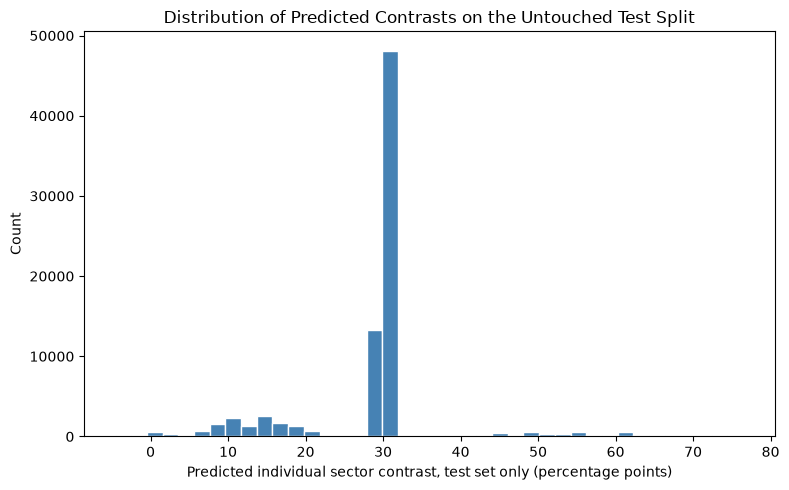

Saved: C:\Users\Tushna\IPD\extensions_work\02_causal_heterogeneity\outputs\heterogeneity_distribution.png


In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(tau_pred_test * 100, bins=40, color="steelblue", edgecolor="white")
ax.set_xlabel("Predicted individual sector contrast, test set only (percentage points)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Predicted Contrasts on the Untouched Test Split")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "heterogeneity_distribution.png", dpi=200)
plt.show()
print("Saved:", OUTPUTS_DIR / "heterogeneity_distribution.png")

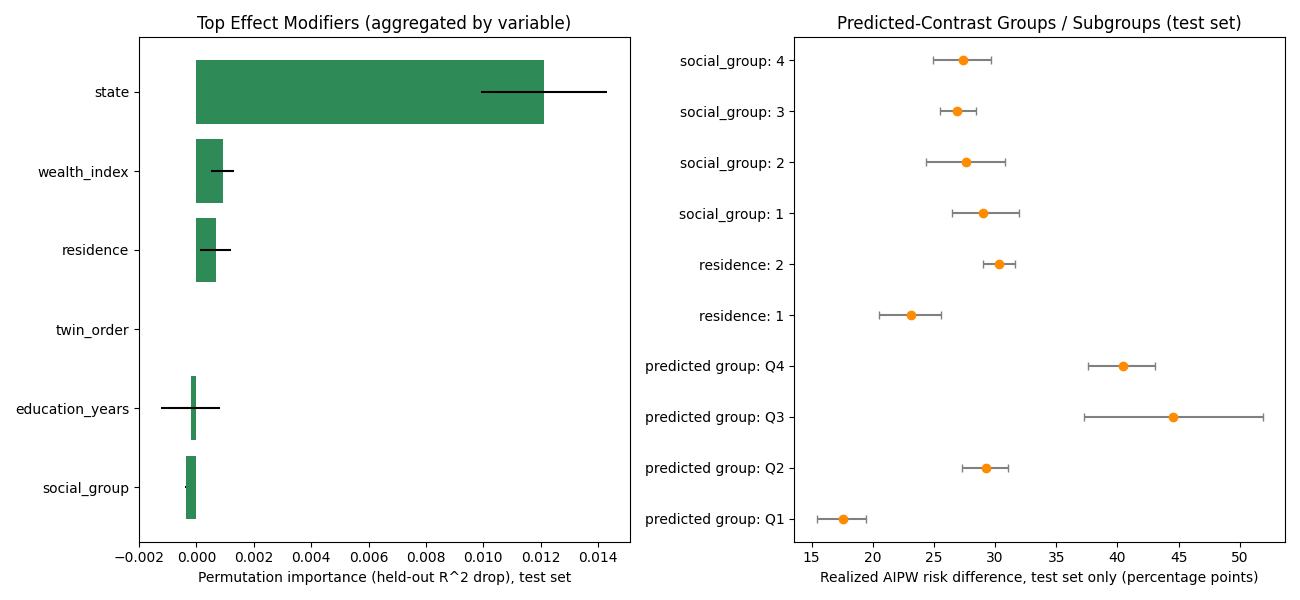

Saved: C:\Users\Tushna\IPD\extensions_work\02_causal_heterogeneity\outputs\heterogeneity_subgroups.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

top_modifiers = modifier_summary.head(10).iloc[::-1]
axes[0].barh(
    top_modifiers["variable"],
    top_modifiers["importance_mean"],
    xerr=top_modifiers["importance_std"],
    color="seagreen",
)
axes[0].set_xlabel("Permutation importance (held-out R^2 drop), test set")
axes[0].set_title("Top Effect Modifiers (aggregated by variable)")

plot_rows = heterogeneity_summary.sort_values(
    ["grouping_variable", "group_label"]
)
y_pos = np.arange(len(plot_rows))
axes[1].errorbar(
    plot_rows["realized_aipw_rd_pp"],
    y_pos,
    xerr=[
        plot_rows["realized_aipw_rd_pp"]
        - plot_rows["realized_aipw_rd_ci_low_pp"],
        plot_rows["realized_aipw_rd_ci_high_pp"]
        - plot_rows["realized_aipw_rd_pp"],
    ],
    fmt="o",
    color="darkorange",
    ecolor="gray",
    capsize=3,
)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(
    plot_rows["grouping_variable"].replace({"cate_predicted_quintile": "predicted group"})
    + ": " + plot_rows["group_label"].astype(str)
)
axes[1].set_xlabel(
    "Realized AIPW risk difference, test set only (percentage points)"
)
axes[1].set_title("Predicted-Contrast Groups / Subgroups (test set)")

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "heterogeneity_subgroups.png", dpi=200)
plt.show()
print("Saved:", OUTPUTS_DIR / "heterogeneity_subgroups.png")

## 16. Save metadata

In [27]:
metadata = {
    "random_state": RANDOM_STATE,
    "design": (
        "single respondent-grouped development/test split (60/40), replacing "
        "the prior two-independently-folded-stage design"
    ),
    "n_development": len(dev),
    "n_test": len(test),
    "reused_notebook07_nuisances": bool(REUSED_NOTEBOOK07_NUISANCES),
    "confounder_set_stage1": confounder_cols,
    "moderator_set_primary": PRIMARY_MODERATORS,
    "stage2_cate_model": {
        "learner": (
            "RandomForestRegressor(n_estimators=500, max_depth=6, "
            "min_samples_leaf=200)"
        ),
        "target": (
            "AIPW pseudo-outcome tau_hat = psi1 - psi0 "
            "(Kennedy 2023 DR-learner)"
        ),
        "fit_on": (
            "development split only; test never used in fitting, "
            "preprocessing, or bin-threshold choice"
        ),
    },
    "predicted_contrast_groups": {
        "n_groups": int(N_QUANTILE_BINS),
        "labels": BIN_LABELS,
        "note": (
            "Duplicate development quantile thresholds were dropped; "
            f"ties were kept together. {N_QUANTILE_BINS} unequal groups resulted."
        ),
    },
    "importance_method": (
        "whole-variable permutation before development-fitted one-hot "
        "encoding; weighted R2 drop on a reproducible test subset"
    ),
    "importance_test_n": IMPORTANCE_TEST_N,
    "importance_repeats": IMPORTANCE_REPEATS,
    "importance_base_r2": float(base_r2),
    "headline_contrasts": {
        "method": (
            "joint/paired PSU-cluster bootstrap: one resample per replicate, "
            "both groups' RD and their difference computed from the same draw"
        ),
        "rural_vs_urban": rural_vs_urban,
        "q4_vs_q1": q5_vs_q1,
    },
    "limitations": [
        (
            "Test-set-only evaluation trades effective sample size and "
            "rare-category stability for an auditable holdout. A single "
            "split is not independent replication."
        ),
        (
            "The joint bootstrap is conditional on the already-fitted "
            "Stage-1 and Stage-2 models; it does not refit the full pipeline "
            "inside each replicate."
        ),
        (
            "Permutation importance uses a held-out subsample and five "
            "repetitions. The low pseudo-outcome predictive R2 limits "
            "interpretation of the ranking."
        ),
        (
            "The four predicted-contrast groups are unequal because of tied "
            "predictions. Realized effects are not strictly monotonic; Q3 "
            "has only 2,334 records."
        ),
    ],
    "interpretation_rule": (
        "Exploratory heterogeneity in an adjusted associational sector "
        "contrast. Not personalized causal truth. Validated on one held-out "
        "test split, not independently replicated."
    ),
}

with open(OUTPUTS_DIR / "heterogeneity_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("Saved:", OUTPUTS_DIR / "heterogeneity_metadata.json")

Saved: C:\Users\Tushna\IPD\extensions_work\02_causal_heterogeneity\outputs\heterogeneity_metadata.json


## 17. Design decisions and interpretation

**Holdout.** Respondents were separated into development (120,553 records; 94,855 respondents) and
test (80,241 records; 63,237 respondents). Nuisance models, preprocessing, stage-2 fitting and bin
thresholds use development only. Test was scored after fitting. Development pseudo-outcomes use respondent-grouped, cross-fitted nuisance predictions within
development. Separate final nuisance models fit on all development records score test without test fitting.

**Prediction and grouping.** Whole-variable permutation importance is measured on 10,000 held-out
records with five repetitions. Weighted pseudo-outcome prediction R-squared is only 0.0061, limiting
ranking interpretation. Tied development predictions yielded four unequal groups Q1-Q4; realized
adjusted contrasts were not monotonic (Q3 exceeds Q4; Q3 has 2,334 records).

**Paired contrasts.** The rural-minus-urban and Q4-minus-Q1 differences use within-stratum PSU
resampling of test records, computing both group risk differences in each replicate. Their intervals
hold fitted models fixed and do not capture full model-fitting or split uncertainty.

**Interpretation.** These are exploratory differences in a standardized private-public sector
association among institutional births. They do not establish a causal effect of changing sector,
identify any state-level mechanism, or independently replicate across splits. See the updated README.
